# `TracerPDF` demo: usage, conditional/marginal PDFs, bias models

This notebook demonstrates the unified `TracerPDF` (`SSLimPy.LIMsurvey.tracer_pdf`):
basic usage, the conditional $P(N_t\mid\delta_m)$ and marginal $P(N_t)$
(via both the original continuous route and the new CosMomentum-validated
discrete route), and a side-by-side comparison of the three bias models.

Sanity check first -- confirm the notebook is actually running the file you
think it is (see the module's own `_BUILD_TAG` note).

In [1]:
import sys
sys.path.append("../")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import astropy.units as u
import warnings

from SSLimPy.interface import sslimpy
from SSLimPy.interface import updater
from SSLimPy.LIMsurvey import voxel_intensity
from SSLimPy.LIMsurvey import tracer_pdf

## 1. Cosmology, halo model, `MatterDensityPDF`

Same setup as the other demo/comparison notebooks in this project.

In [2]:
settings = {
    "code": "class",
    "nonlinearMatpow": True,
    "output": [],
    "kmin": 1e-4 * u.Mpc**-1,
    "kmax": 300 * u.Mpc**-1,
    "nk": 400,
}
cosmodict = {
    "h": 0.70,
    "Omegam": 0.3,
    "As": 2.1e-9,
    "Omegab": 0.05,
}

myssl = sslimpy.SSLimPy(settings_dict=settings, cosmopars=cosmodict)

halo_dict = {
    "hmf_model": "Tinker",
    "bias_model": "Tinker05",
    "halo_tracer": "matter",
}
myhalo = updater.update_halomodel(myssl.current_halomodel, cosmodict, halo_dict, myssl.cfg)

survey_dict = {
    "Tsys_NEFD": 40 * u.uK, "Nfeeds": 19, "tobs": 1300 * u.h, "nD": 1,
    "beam_FWHM": 4.0 * u.arcmin, "nu": 1.897 * u.THz, "dnu": 900 * u.MHz,
    "nuObs": 250 * u.GHz, "Delta_nu": 50 * u.GHz, "Omega_field": 140 * u.deg**2,
}
astrodict_CII = {
    "model_type": "ML", "model_name": "SilvaCII",
    "model_par": {"a": 0.8475, "b": 7.2203, "SFR_file": "sfr_release.dat", "do_quench": False},
    "sigma_scatter": 0.37, "meanperserve_scatter": True,
}
myastro = updater.update_astro(
    myssl.current_astro, cosmodict, halo_dict, astrodict_CII, survey_dict, myssl.cfg
)

matter_pdf = voxel_intensity.MatterDensityPDF(myastro)
R0, z0 = 8.0 * u.Mpc, 0.5

  █████   █████  █       █            █████   █    █ 
 █     █ █     █ █            █   █   █    █  █   █  
 █       █       █     ███   █ █ █ █  █    █   █ █   
  █████   █████  █       █   █  █  █  █████     █    
       █       █ █       █   █     █  █        █     
 █     █ █     █ █       █   █     █  █       █      
  █████   █████  █████ █████ █     █  █      █       

#---------------------------------------------------#


/home/chema/miniconda3/envs/lim/lib/python3.12/site-packages/astropy/units/quantity.py:648: RuntimeWarning: divide by zero encountered in log10
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/home/chema/postdoc/LIM/src/SSLimPy/notebooks/../SSLimPy/cosmology/astro.py:166: RuntimeWarning: divide by zero encountered in log
  np.log(L_of_M.value)[:, None, :] - 0.5 * sigma_base_e**2.0,


## 2. Basic usage

Construct a `TracerPDF` once per tracer sample/redshift -- `N_bar`, the
bias parameters, and the shot-noise parameters don't change per query.

`bias_model="gaussian_lagrangian"` (the default, shown here) is the
RECOMMENDED model for LIM production use -- positive by construction, no
artificial floor in the underdense tail. The other two models
(`"eulerian_quadratic"`, `"additive_lagrangian"`) exist mainly for
cross-checking against CosMomentum -- see Section 4.

In [3]:
N_bar_toy = 50.0        # mean tracer count in the cell -- get this from your AstroFunctions/LF machinery
b1_G, b2_G = 1.5, 0.3    # toy bias params -- refit for your real tracer sample
alpha0, alpha1, alpha2 = 1.0, 0.0, 0.0   # plain Poisson to start

tracer = tracer_pdf.TracerPDF(
    matter_pdf, N_bar=N_bar_toy, b1_G=b1_G, b2_G=b2_G,
    alpha0=alpha0, alpha1=alpha1, alpha2=alpha2,
    # bias_model="gaussian_lagrangian" is the default -- no need to pass it
)

print(f"bias_model = {tracer.bias_model}, bias_mode = {tracer.bias_mode}")
print(f"bias(delta_m=0.3) = {tracer.bias_function(0.3, R0, z0).item():.4f}")

bias_model = gaussian_lagrangian, bias_mode = exact
bias(delta_m=0.3) = 2.2785


## 3. Conditional $P(N_t\mid\delta_m)$

Continuous density (`pdf_Ne_given_delta_m`) vs. proper discrete PMF
(`pmf_Ne_given_delta_m_integer`) at a few fixed $\delta_m$ -- see the
module docstring for why these differ (the discrete PMF bin-integrates
the continuous density, matching how histograms are usually compared
against).

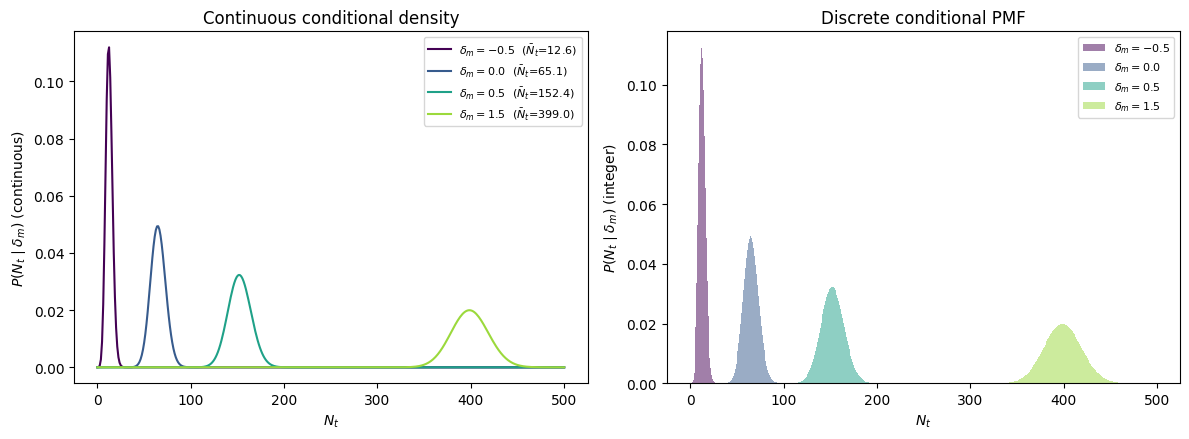

In [4]:
delta_m_values = [-0.5, 0.0, 0.5, 1.5]
N_t_continuous = np.linspace(0, 500, 400)
N_t_int = np.arange(0, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = cm.viridis(np.linspace(0, 0.85, len(delta_m_values)))

for dm, c in zip(delta_m_values, colors):
    dens = tracer.pdf_Ne_given_delta_m(N_t_continuous, dm, R0, z0)
    pmf = tracer.pmf_Ne_given_delta_m_integer(N_t_int, dm, R0, z0)
    N_bar_e = tracer.mean_Ne_given_delta_m(dm, R0, z0).item()
    axes[0].plot(N_t_continuous, dens, color=c, label=rf"$\delta_m={dm}$  ($\bar N_t$={N_bar_e:.1f})")
    axes[1].bar(N_t_int, pmf, width=1.0, color=c, alpha=0.5, label=rf"$\delta_m={dm}$")

axes[0].set_xlabel(r"$N_t$"); axes[0].set_ylabel(r"$P(N_t\mid\delta_m)$ (continuous)")
axes[0].set_title("Continuous conditional density"); axes[0].legend(fontsize=8)
axes[1].set_xlabel(r"$N_t$"); axes[1].set_ylabel(r"$P(N_t\mid\delta_m)$ (integer)")
axes[1].set_title("Discrete conditional PMF"); axes[1].legend(fontsize=8)
plt.tight_layout()

## 4. Marginal $P(N_t)$

$P(N_t) = \int P(N_t\mid\delta_m)\,P(\delta_m)\,d\delta_m$, via `marginal_pmf`
-- a literal port of `GalaxySample::return_CIC_from_matter_density_PDF`
(evaluate the conditional formula DIRECTLY at each integer $N_t$,
renormalise that row to sum to exactly 1, then integrate over $\delta_m$
with the trapezoidal rule), validated against real CosMomentum output.

This is the only marginal route in this module -- it scales to the wide,
long-tailed distributions typical here (its cost depends on the size of
the $\delta_m$ grid, not on how far the $N_t$ tail reaches), and once
`bias_function`'s normalisation was made independent of `method`, it's
simply the more robust of the two routes an earlier version offered.

N_max = 2000, sum(P) = 1.0005  (should be ~1)


(0.0, 200.0)

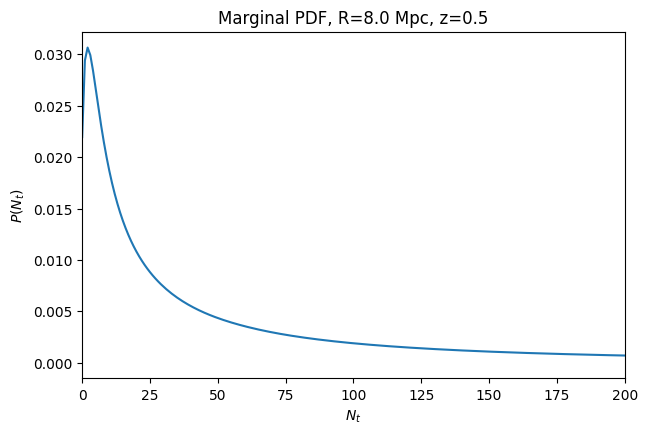

In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    N_grid, P_of_N = tracer.marginal_pmf(R0, z0, N_max='auto')

print(f"N_max = {N_grid.max():.0f}, sum(P) = {P_of_N.sum():.4f}  (should be ~1)")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(N_grid, P_of_N, "-")
ax.set_xlabel(r"$N_t$"); ax.set_ylabel(r"$P(N_t)$")
ax.set_title(f"Marginal PDF, R={R0}, z={z0}")
ax.set_xlim(0, 200)

## 5. Comparing the three bias models

- `"gaussian_lagrangian"` (default, recommended): positive by construction.
- `"eulerian_quadratic"`: simpler quadratic Eulerian bias.
- `"additive_lagrangian"`, `bias_mode="tree"`: CosMomentum's own bias model,
  fast tree-level (point-evaluated) bias terms.
- `"additive_lagrangian"`, `bias_mode="exact"`: same model, but bias terms
  via the exact contour-integral conditional expectation (validated against
  real CosMomentum output) -- expensive (builds/caches a `CGFInverter`),
  falls back to tree-level outside the numerically reliable $\delta_m$
  window.

**Note**: `b1_G`/`b2_G` mean different things for `"eulerian_quadratic"`
(Eulerian bias) vs. the two Lagrangian models -- the toy values below are
NOT meant to be physically equivalent across panels, just illustrative of
each model's shape.

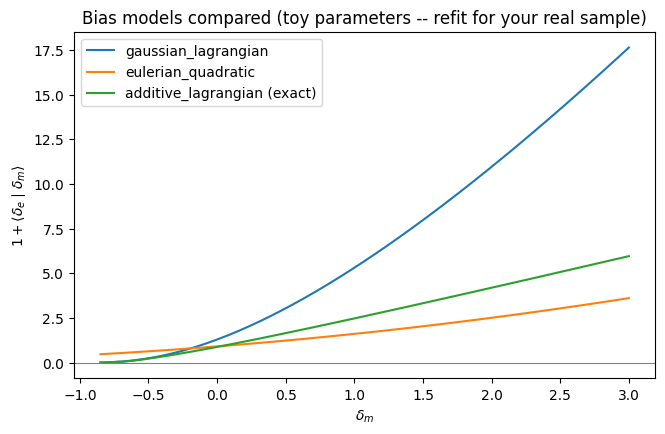

In [6]:
tracers = {
    "gaussian_lagrangian": tracer_pdf.TracerPDF(
        matter_pdf, N_bar=N_bar_toy, b1_G=1.5, b2_G=0.3, bias_model="gaussian_lagrangian",
    ),
    "eulerian_quadratic": tracer_pdf.TracerPDF(
        matter_pdf, N_bar=N_bar_toy, b1_G=0.6, b2_G=0.2, bias_model="eulerian_quadratic",
    ),
    "additive_lagrangian (exact)": tracer_pdf.TracerPDF(
        matter_pdf, N_bar=N_bar_toy, b1_G=0.6, b2_G=0.2, bias_model="additive_lagrangian", bias_mode="exact",
    ),
}

delta_m_compare = np.linspace(-0.85, 3.0, 200)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # the additive models' one-time clip warning is expected
    for name, tr in tracers.items():
        bias_vals = tr.bias_function(delta_m_compare, R0, z0)
        ax.plot(delta_m_compare, bias_vals, label=name)

ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel(r"$\delta_m$"); ax.set_ylabel(r"$1+\langle\delta_e\mid\delta_m\rangle$")
ax.set_title("Bias models compared (toy parameters -- refit for your real sample)")
ax.legend()

### 5b. Conditional $P(N_t\mid\delta_m)$ at one $\delta_m$, all four models

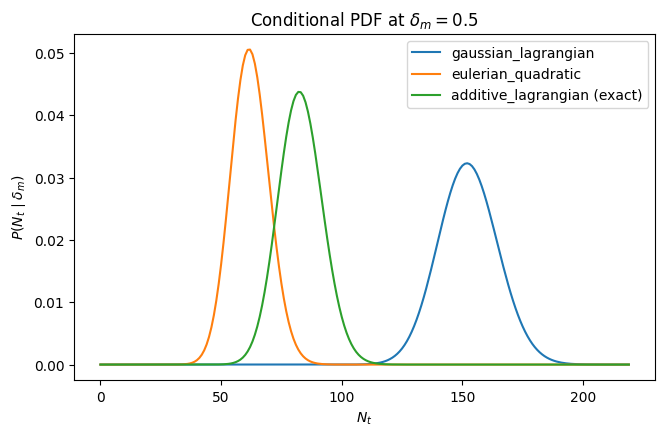

In [7]:
delta_m_of_interest = 0.5
N_range = np.arange(0, 220)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, tr in tracers.items():
        pmf = tr.pmf_Ne_given_delta_m_integer(N_range, delta_m_of_interest, R0, z0)
        ax.plot(N_range, pmf, label=name)

ax.set_xlabel(r"$N_t$"); ax.set_ylabel(r"$P(N_t\mid\delta_m)$")
ax.set_title(rf"Conditional PDF at $\delta_m={delta_m_of_interest}$")
ax.legend()

### 5c. Marginal $P(N_t)$, all four models

Uses `marginal_pmf` (the CosMomentum-validated route) for all four --
works with any `bias_model`, not just `"additive_lagrangian"`.

(-1.0, 200.0)

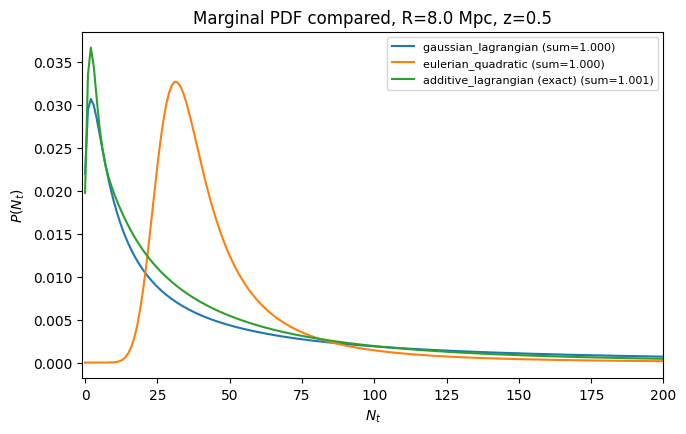

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for name, tr in tracers.items():
        N_grid, P_of_N = tr.marginal_pmf(R0, z0, N_max=1000)
        ax.plot(N_grid, P_of_N, label=f"{name} (sum={P_of_N.sum():.3f})")

ax.set_xlabel(r"$N_t$"); ax.set_ylabel(r"$P(N_t)$")
ax.set_title(f"Marginal PDF compared, R={R0}, z={z0}")
ax.legend(fontsize=8)
ax.set_xlim(-1, 200)

## Summary

- One `TracerPDF` per tracer sample/redshift; `bias_model="gaussian_lagrangian"`
  (the default) is what to use for actual LIM science.
- `pdf_Ne_given_delta_m`/`pmf_Ne_given_delta_m_integer` -- conditional,
  continuous density vs. proper discrete PMF.
- `marginal_pmf` -- the only marginal route (CosMomentum's own discrete
  algorithm, works with any bias model); scales with the size of the
  $\delta_m$ grid, not with how far the $N_t$ tail reaches, which matters
  for wide-tailed distributions like this project's.
- `"additive_lagrangian"` with `bias_mode="exact"` is the most accurate
  (validated against real CosMomentum output) but the most expensive, and
  only reliable within a numerically bounded $\delta_m$ window (falls back
  to tree-level outside it) -- mainly useful for cross-checking, not
  routine use.